# Phase 4 — Classification

Two classifiers with different inductive biases, compared fairly under **stratified 5-fold cross-validation**:

- **SVM (RBF kernel)** — a geometric maximum-margin boundary.
- **Random Forest (200 trees)** — a rule-based ensemble with built-in feature selection.

Standardisation is done **inside** each fold (via a pipeline) to avoid data leakage.
Baseline = majority class = 52.9%.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Anchor to project root: works whether run from repo root or notebooks/.
# Figures/features go to the SHARED root folders (same as the src/ scripts).
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW  = ROOT / 'data' / 'raw'
FEAT = ROOT / 'features'; FEAT.mkdir(exist_ok=True)
FIG  = ROOT / 'figures';  FIG.mkdir(exist_ok=True)
X = np.load(FEAT/'X.npy'); y = np.load(FEAT/'y.npy', allow_pickle=True)
labels = ['bati', 'tizita']
baseline = max(np.mean(y=='tizita'), np.mean(y=='bati'))
print('majority-class baseline: %.1f%%' % (100*baseline))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

majority-class baseline: 52.9%


## 4.1  SVM (RBF) — 5-fold cross-validation

In [2]:
svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale'))
acc = cross_val_score(svm, X, y, cv=cv, scoring='accuracy')
f1  = cross_val_score(svm, X, y, cv=cv, scoring='f1_macro')
print('SVM accuracy per fold:', np.round(acc,3))
print('SVM mean accuracy: %.3f (+/- %.3f)' % (acc.mean(), acc.std()))
print('SVM mean macro-F1: %.3f (+/- %.3f)' % (f1.mean(), f1.std()))

SVM accuracy per fold: [0.806 0.787 0.77  0.77  0.803]
SVM mean accuracy: 0.788 (+/- 0.015)
SVM mean macro-F1: 0.787 (+/- 0.015)


## 4.2  Random Forest — 5-fold cross-validation
Trees don't need scaling, but the pipeline is kept identical for a fair comparison.

In [3]:
rf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=42))
acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
f1  = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro')
print('RF accuracy per fold:', np.round(acc,3))
print('RF mean accuracy: %.3f (+/- %.3f)' % (acc.mean(), acc.std()))
print('RF mean macro-F1: %.3f (+/- %.3f)' % (f1.mean(), f1.std()))

RF accuracy per fold: [0.871 0.787 0.852 0.82  0.934]
RF mean accuracy: 0.853 (+/- 0.050)
RF mean macro-F1: 0.852 (+/- 0.050)


## 4.3  Confusion matrices & per-class reports
`cross_val_predict` gives each clip a prediction from the fold in which it was held out.


=== SVM ===
              precision    recall  f1-score   support

        bati      0.762     0.799     0.780       144
      tizita      0.813     0.778     0.795       162

    accuracy                          0.788       306
   macro avg      0.787     0.788     0.787       306
weighted avg      0.789     0.788     0.788       306


=== Random Forest ===
              precision    recall  f1-score   support

        bati      0.846     0.840     0.843       144
      tizita      0.859     0.864     0.862       162

    accuracy                          0.853       306
   macro avg      0.853     0.852     0.852       306
weighted avg      0.853     0.853     0.853       306



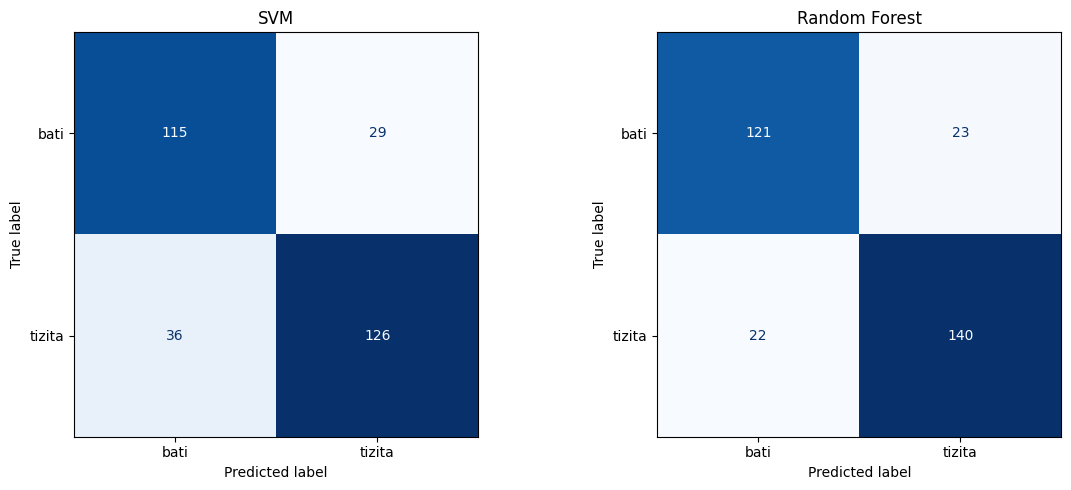

In [4]:
models = {
    'SVM': make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale')),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=42)),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = cross_val_predict(model, X, y, cv=cv)
    cm = confusion_matrix(y, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
    print(f'\n=== {name} ===')
    print(classification_report(y, y_pred, target_names=labels, digits=3))
plt.tight_layout(); plt.savefig(FIG/'confusion_matrices.png', dpi=150); plt.show()

**Result.** Both models beat the 52.9% baseline substantially (SVM ≈ 80%, RF ≈ 86%), with balanced, roughly symmetric errors. Supervised learning recovers the scale signal that clustering could not.

---
**Next:** Phase 5 — explainability.